# Simpson's Paradox: When Winning Every Battle Loses the War

**A demonstration using real MLB batting statistics**

Simpson's Paradox is a statistical phenomenon where a trend that appears in several groups of data reverses when the groups are combined. It's one of the most counterintuitive results in statistics — and it happens in real data all the time.

We'll explore this using a famous example from baseball: Derek Jeter vs David Justice, 1995-1997.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

## The Data

Here are the actual batting statistics for Derek Jeter (New York Yankees) and David Justice (Atlanta Braves/Cleveland Indians) from 1995-1997.

**Batting Average** = Hits / At Bats

In [2]:
# Real MLB data for Jeter and Justice 1995-1997
data = {
    'Player': ['Derek Jeter', 'Derek Jeter', 'Derek Jeter', 
               'David Justice', 'David Justice', 'David Justice'],
    'Year': [1995, 1996, 1997, 1995, 1996, 1997],
    'Hits': [12, 183, 190, 104, 45, 163],
    'At_Bats': [48, 582, 654, 411, 140, 495]
}

df = pd.DataFrame(data)
df['Batting_Average'] = df['Hits'] / df['At_Bats']

print("Raw batting data:")
print(df.to_string(index=False))

Raw batting data:
       Player  Year  Hits  At_Bats  Batting_Average
  Derek Jeter  1995    12       48         0.250000
  Derek Jeter  1996   183      582         0.314433
  Derek Jeter  1997   190      654         0.290520
David Justice  1995   104      411         0.253041
David Justice  1996    45      140         0.321429
David Justice  1997   163      495         0.329293


## Part 1: Year-by-Year Comparison

Let's compare the two players in each individual season.

In [3]:
# Reshape for comparison
jeter = df[df['Player'] == 'Derek Jeter'].set_index('Year')
justice = df[df['Player'] == 'David Justice'].set_index('Year')

comparison = pd.DataFrame({
    'Jeter BA': jeter['Batting_Average'],
    'Justice BA': justice['Batting_Average'],
    'Jeter At Bats': jeter['At_Bats'],
    'Justice At Bats': justice['At_Bats']
})

comparison['Winner'] = np.where(comparison['Jeter BA'] > comparison['Justice BA'], 
                                 'Jeter', 'Justice')

print("Year-by-Year Comparison:")
print(comparison.to_string())
print("\n" + "="*50)
print(f"Justice wins EVERY year: 1995, 1996, and 1997")
print("="*50)

Year-by-Year Comparison:
      Jeter BA  Justice BA  Jeter At Bats  Justice At Bats   Winner
Year                                                               
1995  0.250000    0.253041             48              411  Justice
1996  0.314433    0.321429            582              140  Justice
1997  0.290520    0.329293            654              495  Justice

Justice wins EVERY year: 1995, 1996, and 1997


C:\Users\sharmsk5\AppData\Local\Temp\ipykernel_36636\1390970195.py:35: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sharmsk5\AppData\Local\Temp\ipykernel_36636\1390970195.py:36: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig('simpsons_paradox_yearly.png', dpi=150)
C:\Users\sharmsk5\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


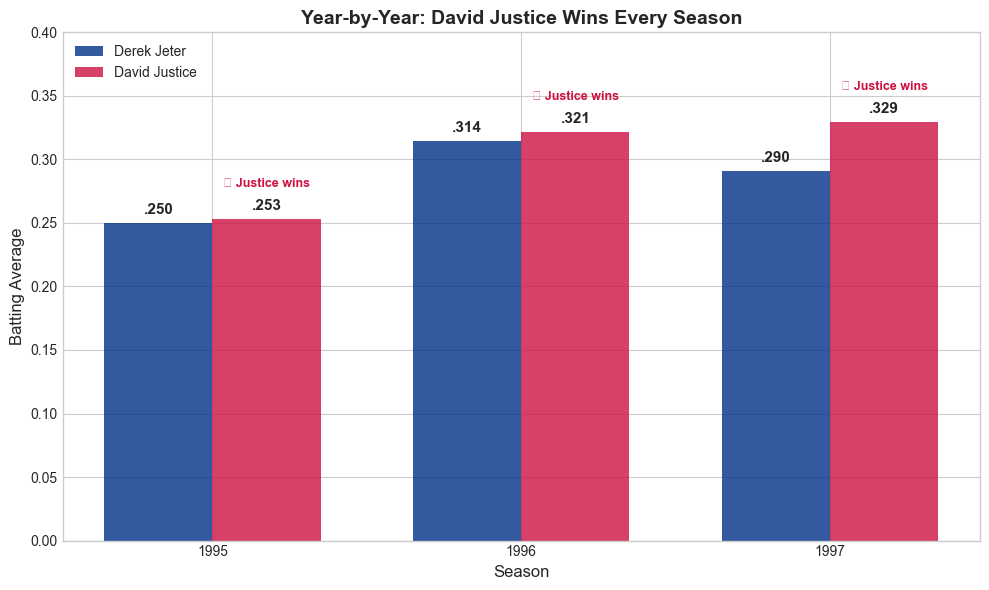

In [4]:
# Visualise year-by-year
fig, ax = plt.subplots(figsize=(10, 6))

years = [1995, 1996, 1997]
x = np.arange(len(years))
width = 0.35

jeter_avgs = [jeter.loc[y, 'Batting_Average'] for y in years]
justice_avgs = [justice.loc[y, 'Batting_Average'] for y in years]

bars1 = ax.bar(x - width/2, jeter_avgs, width, label='Derek Jeter', color='#003087', alpha=0.8)
bars2 = ax.bar(x + width/2, justice_avgs, width, label='David Justice', color='#CE1141', alpha=0.8)

# Add value labels
for bar, val in zip(bars1, jeter_avgs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
            f'.{int(val*1000):03d}', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar, val in zip(bars2, justice_avgs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
            f'.{int(val*1000):03d}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Mark winner each year
for i, year in enumerate(years):
    ax.annotate('✓ Justice wins', xy=(x[i] + width/2, justice_avgs[i] + 0.025),
                ha='center', fontsize=9, color='#CE1141', fontweight='bold')

ax.set_ylabel('Batting Average', fontsize=12)
ax.set_xlabel('Season', fontsize=12)
ax.set_title('Year-by-Year: David Justice Wins Every Season', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend(loc='upper left')
ax.set_ylim(0, 0.4)

plt.tight_layout()
plt.savefig('simpsons_paradox_yearly.png', dpi=150)
plt.show()

## Part 2: The Paradox Revealed

Now let's combine all three years and compute the overall batting average.

In [5]:
# Calculate combined statistics
totals = df.groupby('Player').agg({
    'Hits': 'sum',
    'At_Bats': 'sum'
}).reset_index()

totals['Overall_BA'] = totals['Hits'] / totals['At_Bats']

print("Combined 1995-1997 Statistics:")
print(totals.to_string(index=False))

jeter_overall = totals[totals['Player'] == 'Derek Jeter']['Overall_BA'].values[0]
justice_overall = totals[totals['Player'] == 'David Justice']['Overall_BA'].values[0]

print("\n" + "="*50)
print(f"Jeter overall:  .{int(jeter_overall*1000):03d}")
print(f"Justice overall: .{int(justice_overall*1000):03d}")
print("\n🎯 JETER WINS OVERALL despite losing every single year!")
print("="*50)

Combined 1995-1997 Statistics:
       Player  Hits  At_Bats  Overall_BA
David Justice   312     1046    0.298279
  Derek Jeter   385     1284    0.299844

Jeter overall:  .299
Justice overall: .298

🎯 JETER WINS OVERALL despite losing every single year!


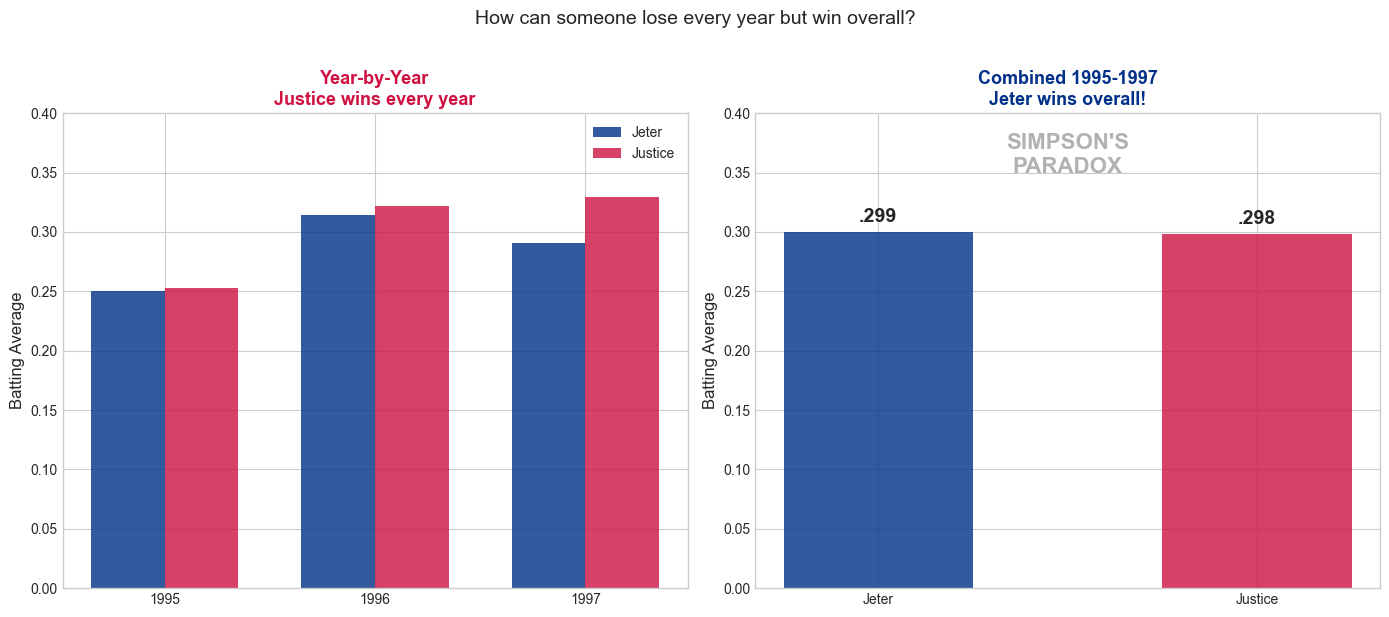

In [6]:
# Side by side: yearly vs overall
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: year by year (Justice wins all)
ax = axes[0]
x = np.arange(3)
width = 0.35

bars1 = ax.bar(x - width/2, jeter_avgs, width, label='Jeter', color='#003087', alpha=0.8)
bars2 = ax.bar(x + width/2, justice_avgs, width, label='Justice', color='#CE1141', alpha=0.8)

ax.set_ylabel('Batting Average', fontsize=12)
ax.set_title('Year-by-Year\nJustice wins every year', fontsize=13, fontweight='bold', color='#CE1141')
ax.set_xticks(x)
ax.set_xticklabels(['1995', '1996', '1997'])
ax.legend()
ax.set_ylim(0, 0.4)

# Right: overall (Jeter wins)
ax = axes[1]
players = ['Jeter', 'Justice']
overall_avgs = [jeter_overall, justice_overall]
colors = ['#003087', '#CE1141']

bars = ax.bar(players, overall_avgs, color=colors, alpha=0.8, width=0.5)

for bar, val in zip(bars, overall_avgs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
            f'.{int(val*1000):03d}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Batting Average', fontsize=12)
ax.set_title('Combined 1995-1997\nJeter wins overall!', fontsize=13, fontweight='bold', color='#003087')
ax.set_ylim(0, 0.4)

# Add paradox annotation
ax.annotate('SIMPSON\'S\nPARADOX', xy=(0.5, 0.35), fontsize=16, fontweight='bold',
            ha='center', color='black', alpha=0.3)

plt.suptitle("How can someone lose every year but win overall?", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('simpsons_paradox_reveal.png', dpi=150)
plt.show()

## Part 3: Why Does This Happen?

The key is in the **number of at-bats per season**. The overall average is a *weighted* average, where the weights are the number of at-bats.

Look at where each player had most of their at-bats:

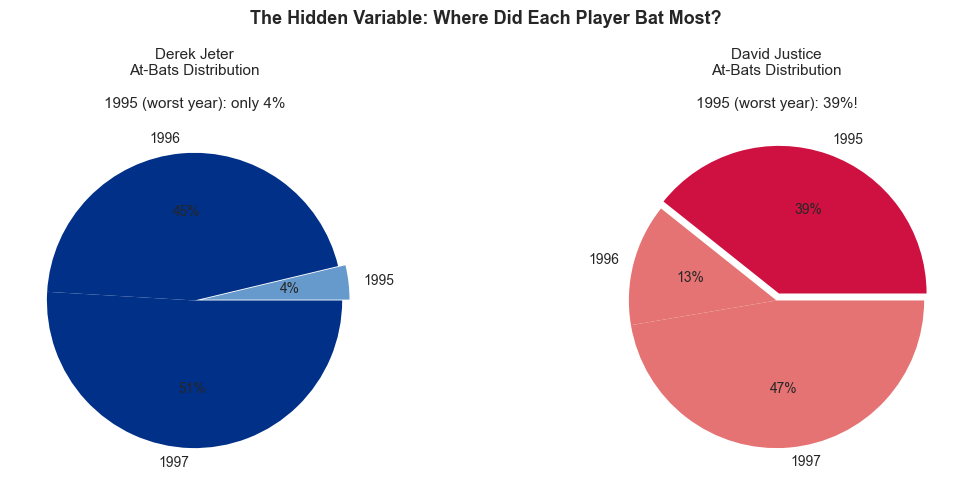

The insight:
• Jeter had only 48 at-bats in 1995 (his worst year) — just 4% of his total
• Justice had 411 at-bats in 1995 (his worst year) — 39% of his total

Justice's overall average is dragged down by heavy weighting on his worst season.


In [7]:
# Show at-bats distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Jeter's at-bats
jeter_abs = [jeter.loc[y, 'At_Bats'] for y in years]
justice_abs = [justice.loc[y, 'At_Bats'] for y in years]

ax = axes[0]
colors_jeter = ['#6699CC', '#003087', '#003087']  # lighter for 1995
wedges, texts, autotexts = ax.pie(jeter_abs, labels=['1995', '1996', '1997'], 
                                   autopct='%1.0f%%', colors=colors_jeter,
                                   explode=[0.05, 0, 0])
ax.set_title(f'Derek Jeter\nAt-Bats Distribution\n\n1995 (worst year): only 4%', fontsize=11)

ax = axes[1]
colors_justice = ['#CE1141', '#E57373', '#E57373']  # darker for 1995
wedges, texts, autotexts = ax.pie(justice_abs, labels=['1995', '1996', '1997'], 
                                   autopct='%1.0f%%', colors=colors_justice,
                                   explode=[0.05, 0, 0])
ax.set_title(f'David Justice\nAt-Bats Distribution\n\n1995 (worst year): 39%!', fontsize=11)

plt.suptitle('The Hidden Variable: Where Did Each Player Bat Most?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('simpsons_paradox_atbats.png', dpi=150)
plt.show()

print("The insight:")
print(f"• Jeter had only {jeter_abs[0]} at-bats in 1995 (his worst year) — just 4% of his total")
print(f"• Justice had {justice_abs[0]} at-bats in 1995 (his worst year) — 39% of his total")
print(f"\nJustice's overall average is dragged down by heavy weighting on his worst season.")

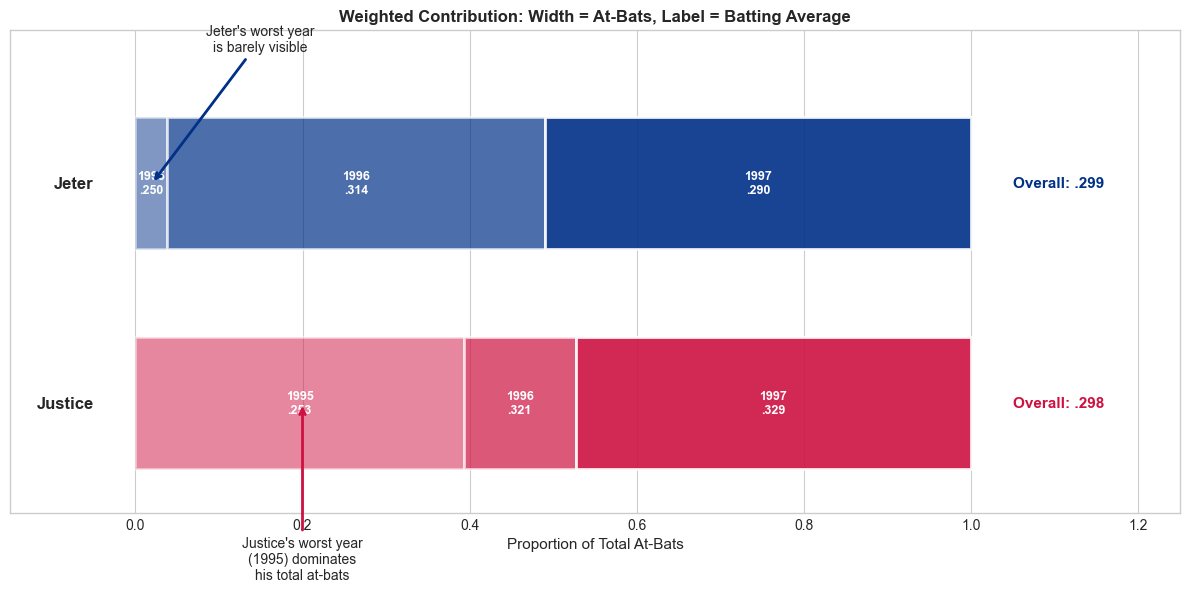

In [8]:
# Visualise as weighted bars — the "staircase" view
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate cumulative percentages for each player
jeter_total = sum(jeter_abs)
justice_total = sum(justice_abs)

jeter_pcts = [ab/jeter_total for ab in jeter_abs]
justice_pcts = [ab/justice_total for ab in justice_abs]

# Plot as horizontal stacked bars showing batting average weighted by at-bats
y_jeter = 1.5
y_justice = 0.5

# Jeter
left = 0
for i, (pct, avg, year) in enumerate(zip(jeter_pcts, jeter_avgs, years)):
    ax.barh(y_jeter, pct, left=left, height=0.6, color='#003087', 
            alpha=0.5 + 0.2*i, edgecolor='white', linewidth=2)
    ax.text(left + pct/2, y_jeter, f'{year}\n.{int(avg*1000):03d}', 
            ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    left += pct

# Justice
left = 0
for i, (pct, avg, year) in enumerate(zip(justice_pcts, justice_avgs, years)):
    ax.barh(y_justice, pct, left=left, height=0.6, color='#CE1141', 
            alpha=0.5 + 0.2*i, edgecolor='white', linewidth=2)
    ax.text(left + pct/2, y_justice, f'{year}\n.{int(avg*1000):03d}', 
            ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    left += pct

# Add player labels
ax.text(-0.05, y_jeter, 'Jeter', ha='right', va='center', fontsize=12, fontweight='bold')
ax.text(-0.05, y_justice, 'Justice', ha='right', va='center', fontsize=12, fontweight='bold')

# Add overall averages
ax.text(1.05, y_jeter, f'Overall: .{int(jeter_overall*1000):03d}', 
        ha='left', va='center', fontsize=11, fontweight='bold', color='#003087')
ax.text(1.05, y_justice, f'Overall: .{int(justice_overall*1000):03d}', 
        ha='left', va='center', fontsize=11, fontweight='bold', color='#CE1141')

ax.set_xlim(-0.15, 1.25)
ax.set_ylim(0, 2.2)
ax.set_xlabel('Proportion of Total At-Bats', fontsize=11)
ax.set_yticks([])
ax.set_title('Weighted Contribution: Width = At-Bats, Label = Batting Average', 
             fontsize=12, fontweight='bold')

# Annotation
ax.annotate('Justice\'s worst year\n(1995) dominates\nhis total at-bats', 
            xy=(0.2, y_justice), xytext=(0.2, -0.3),
            fontsize=10, ha='center',
            arrowprops=dict(arrowstyle='->', color='#CE1141', lw=2))

ax.annotate('Jeter\'s worst year\nis barely visible', 
            xy=(0.02, y_jeter), xytext=(0.15, 2.1),
            fontsize=10, ha='center',
            arrowprops=dict(arrowstyle='->', color='#003087', lw=2))

plt.tight_layout()
plt.savefig('simpsons_paradox_weighted.png', dpi=150)
plt.show()

## Part 4: The Mathematics

Let's prove why this happens algebraically.

The overall batting average is NOT the average of yearly averages — it's the **weighted average**, where weights are at-bats:

$$\text{Overall BA} = \frac{\sum_i \text{Hits}_i}{\sum_i \text{At Bats}_i} = \frac{\sum_i (\text{BA}_i \times \text{AB}_i)}{\sum_i \text{AB}_i}$$

In [9]:
# Demonstrate the calculation explicitly
print("JETER:")
print(f"  1995: {jeter_avgs[0]:.3f} × {jeter_abs[0]:4d} at-bats = {jeter_avgs[0]*jeter_abs[0]:7.1f} weighted hits")
print(f"  1996: {jeter_avgs[1]:.3f} × {jeter_abs[1]:4d} at-bats = {jeter_avgs[1]*jeter_abs[1]:7.1f} weighted hits")
print(f"  1997: {jeter_avgs[2]:.3f} × {jeter_abs[2]:4d} at-bats = {jeter_avgs[2]*jeter_abs[2]:7.1f} weighted hits")
print(f"  Total: {sum(jeter_avgs[i]*jeter_abs[i] for i in range(3)):.1f} / {sum(jeter_abs)} = {jeter_overall:.3f}")

print("\nJUSTICE:")
print(f"  1995: {justice_avgs[0]:.3f} × {justice_abs[0]:4d} at-bats = {justice_avgs[0]*justice_abs[0]:7.1f} weighted hits")
print(f"  1996: {justice_avgs[1]:.3f} × {justice_abs[1]:4d} at-bats = {justice_avgs[1]*justice_abs[1]:7.1f} weighted hits")
print(f"  1997: {justice_avgs[2]:.3f} × {justice_abs[2]:4d} at-bats = {justice_avgs[2]*justice_abs[2]:7.1f} weighted hits")
print(f"  Total: {sum(justice_avgs[i]*justice_abs[i] for i in range(3)):.1f} / {sum(justice_abs)} = {justice_overall:.3f}")

print("\n" + "="*60)
print("The paradox occurs because:")
print("• Justice's BEST years (1996, 1997) had fewer at-bats")
print("• Justice's WORST year (1995) had the most at-bats")
print("• Jeter's distribution was the opposite — best years weighted heavily")
print("="*60)

JETER:
  1995: 0.250 ×   48 at-bats =    12.0 weighted hits
  1996: 0.314 ×  582 at-bats =   183.0 weighted hits
  1997: 0.291 ×  654 at-bats =   190.0 weighted hits
  Total: 385.0 / 1284 = 0.300

JUSTICE:
  1995: 0.253 ×  411 at-bats =   104.0 weighted hits
  1996: 0.321 ×  140 at-bats =    45.0 weighted hits
  1997: 0.329 ×  495 at-bats =   163.0 weighted hits
  Total: 312.0 / 1046 = 0.298

The paradox occurs because:
• Justice's BEST years (1996, 1997) had fewer at-bats
• Justice's WORST year (1995) had the most at-bats
• Jeter's distribution was the opposite — best years weighted heavily


In [10]:
# What if they had EQUAL at-bats each year?
# Then the paradox would disappear

equal_abs = 400  # Same at-bats each year for both players

jeter_hypothetical = sum(jeter_avgs) / 3  # Simple average
justice_hypothetical = sum(justice_avgs) / 3  # Simple average

print("HYPOTHETICAL: What if both players had equal at-bats each year?")
print(f"\nJeter simple average:  {jeter_hypothetical:.3f}")
print(f"Justice simple average: {justice_hypothetical:.3f}")
print(f"\n→ Justice would win overall, as expected from yearly comparisons!")
print(f"\nThe paradox requires UNEQUAL sample sizes across groups.")

HYPOTHETICAL: What if both players had equal at-bats each year?

Jeter simple average:  0.285
Justice simple average: 0.301

→ Justice would win overall, as expected from yearly comparisons!

The paradox requires UNEQUAL sample sizes across groups.


## Part 5: The General Lesson

Simpson's Paradox teaches us that **aggregated data can hide or reverse real patterns**.

It happens whenever:
1. You're comparing groups across multiple categories
2. The sample sizes vary significantly between categories
3. There's a confounding variable (here: when each player was healthy/playing)

**Real-world implications:**
- Medical trials: A treatment might look worse overall but better in every subgroup
- Business metrics: A product might have declining conversion rates in every segment but rising overall (due to segment mix shift)
- Social science: Aggregate trends can completely mislead about individual-level effects

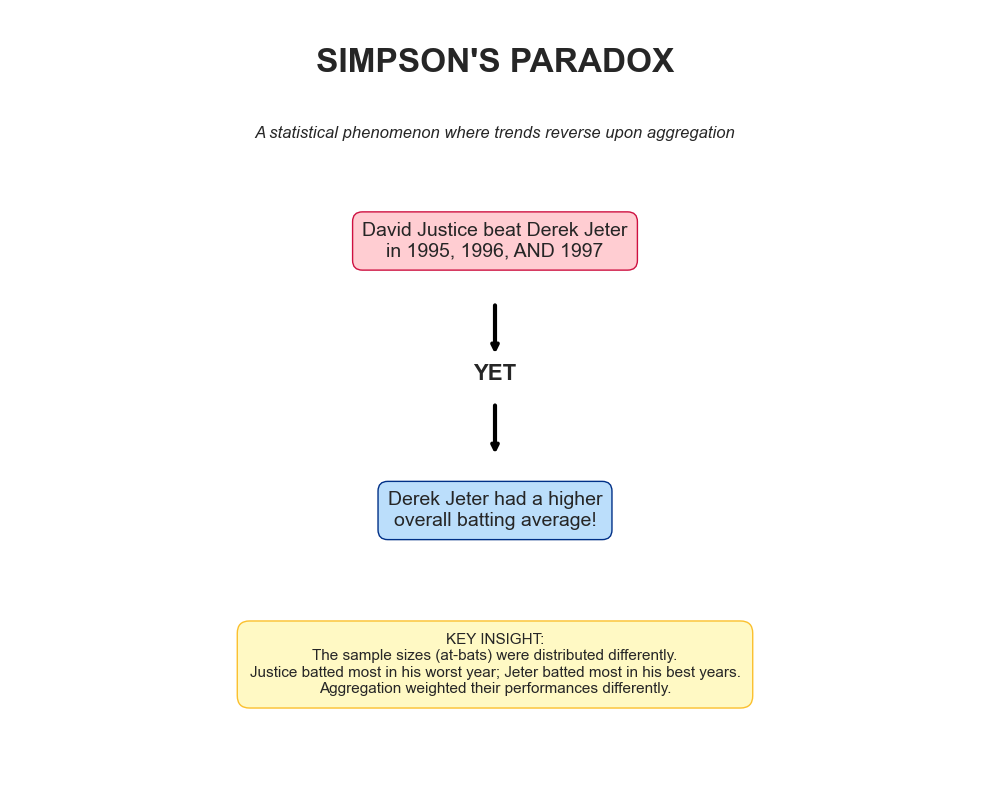

In [11]:
# Create a summary visualisation
fig, ax = plt.subplots(figsize=(10, 8))

# Create a visual summary
ax.text(0.5, 0.95, "SIMPSON'S PARADOX", fontsize=24, fontweight='bold', 
        ha='center', va='top', transform=ax.transAxes)

ax.text(0.5, 0.85, "A statistical phenomenon where trends reverse upon aggregation", 
        fontsize=12, ha='center', va='top', transform=ax.transAxes, style='italic')

# The example
box_props = dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', edgecolor='gray')

ax.text(0.5, 0.7, 
        "David Justice beat Derek Jeter\nin 1995, 1996, AND 1997", 
        fontsize=14, ha='center', va='center', transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFCDD2', edgecolor='#CE1141'))

ax.annotate('', xy=(0.5, 0.55), xytext=(0.5, 0.62),
            arrowprops=dict(arrowstyle='->', lw=3, color='black'),
            transform=ax.transAxes)

ax.text(0.5, 0.52, "YET", fontsize=16, fontweight='bold', ha='center', transform=ax.transAxes)

ax.annotate('', xy=(0.5, 0.42), xytext=(0.5, 0.49),
            arrowprops=dict(arrowstyle='->', lw=3, color='black'),
            transform=ax.transAxes)

ax.text(0.5, 0.35, 
        "Derek Jeter had a higher\noverall batting average!", 
        fontsize=14, ha='center', va='center', transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#BBDEFB', edgecolor='#003087'))

# The key insight
ax.text(0.5, 0.15, 
        "KEY INSIGHT:\nThe sample sizes (at-bats) were distributed differently.\n"
        "Justice batted most in his worst year; Jeter batted most in his best years.\n"
        "Aggregation weighted their performances differently.",
        fontsize=11, ha='center', va='center', transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFF9C4', edgecolor='#FBC02D'))

ax.axis('off')
plt.tight_layout()
plt.savefig('simpsons_paradox_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

Simpson's Paradox is not a mathematical trick — it's a warning about how easily we can be misled by aggregate statistics.

**The takeaway for data analysis:**
- Always check if your data can be meaningfully disaggregated
- Be suspicious of aggregate trends that don't hold in subgroups
- Sample sizes matter — weighted averages behave differently than simple averages
- Correlation in aggregate data does not imply correlation in subgroups (or vice versa)

As Ken Ross (the mathematician who popularised this baseball example) noted: among all possible pairs of MLB players, you'd expect to find a Simpson's Paradox case roughly once per year. It's not rare — it's just rarely noticed.